In [1]:
# import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Структура данных

Датасет представлен в табличном формате и содержит следующие колонки:

`user_id` - идентификатор пользователя

`created_date` - дата создания записи

`nm_id` - идентификатор товара

`total_ordered` - общее количество заказанных товаров

`payment_type` - тип оплаты

`is_paid` - флаг оплаты (булево значение)

`count_items` - количество товаров за последнее время

`unique_items` - количество уникальных товаров за последнее время

`avg_unique_purchase` - среднее количество уникальных покупок за последнее время

`is_courier` - флаг доставки курьером

`nm_age` - возраст товара

`Distance` - расстояние

`days_after_registration` - дни после регистрации

`number_of_orders` - количество заказов

`number_of_ordered_items` - количество заказанных товаров

`mean_number_of_ordered_items` - среднее количество заказанных товаров

`min_number_of_ordered_items` - минимальное количество заказанных товаров

`max_number_of_ordered_items` - максимальное количество заказанных товаров

`mean_percent_of_ordered_items` - средний процент заказанных товаров

`target` - целевая переменная (0 - не требуется блокировка, 1 - требуется блокировка)

`service` - тип региона

Датасет имеет сильный дисбаланс классов в соотношении 1:10 (класс 1 встречается значительно реже).

## Требования к задаче

**Анализ данных (EDA):**
* Исследовать распределение признаков
* Проанализировать дисбаланс (сколько объектов каждого класса)
* Выявить корреляции между признаками
* Проверить наличие пропущенных значений и выбросов

**Предобработка данных:**
* Обработка пропущенных значений
* Кодирование категориальных признаков
* Масштабирование числовых признаков
* Работа с дисбалансом классов (SMOTE, undersampling, class weights и т.д.)

**Построение модели:**
* Любой фреймворк (scikit-learn, XGBoost, LightGBM, CatBoost и т.д.)
* Можно использовать ансамблевые методы
* Учитывать баланс между качеством и скоростью

**Оценка качества:**
* Основные метрики для миноритарного класса: Precision и Recall
* Дополнительные метрики: F1-score, PR-AUC, ROC-AUC
* Обязательная оценка Confusion Matrix

**Подготовка результатов:**
* Валидация: подбираем гиперпараметры
* Тест: итоговая метрика

**Развёртывание сервиса:**
* REST API (Flask/FastAPI) либо UI (Streamlit/Gradio)
* /predict эндпоинт, возвращающий {"prediction": 0 или 1, "confidence": float}

**Отчёт:**
* Описание подхода, модели, метрик
* Результаты на тесте


## Методика оценки

**Оценка качества модели для миноритарного (целевого) класса:**
* Неудовлетворительный результат:
  * Recall < 0.1 при Precision < 0.75
* Хороший результат:
  * 0.1 ≤ Recall при 0.8 ≤ Precision 
* Победитель:
  * Recall ≥ 0.1 при максимальном Precision

**Дополнительные метрики:**
* F1-score — комбинированная метрика Precision и Recall (используется для сравнения моделей)
* PR-AUC — особенно важна для несбалансированных данных
* ROC-AUC — оценка разделительной способности модели

# 1. EDA и Предобработка данных

### 1.1 Скачивание данных

In [2]:
# url = 'https://drive.google.com/uc?export=download&id=1YHw-ZszkSkLo3UwtPu6fWABJGU6kRJJb'
# output = 'df_train.csv'
# gdown.download(url, output, quiet=False)
# data_train = pd.read_csv(output)
# url = 'https://drive.google.com/uc?export=download&id=1YQUMyFUdV-1FQWxpIZ0FugQtQqmgWVi-'
# output = 'df_test.csv'
# gdown.download(url, output, quiet=False)
# data_test = pd.read_csv(output)
data_train = pd.read_csv('df_train.csv')
data_test = pd.read_csv('df_test.csv')

In [3]:
data_train.head()

,user_id,nm_id,CreatedDate,service,total_ordered,PaymentType,IsPaid,count_items,unique_items,avg_unique_purchase,...,NmAge,Distance,DaysAfterRegistration,number_of_orders,number_of_ordered_items,mean_number_of_ordered_items,min_number_of_ordered_items,max_number_of_ordered_items,mean_percent_of_ordered_items,target
0,1,1,2025-01-05 02:20:24+03:00,nnsz,627,CSH,False,4,4,1.00,...,117,3443,73,1,627,627.0,627,627,100.000000,0
1,2,2,2024-11-05 09:05:21+03:00,nnsz,512,CRD,True,0,0,0.00,...,920,3478,1237,2,606,303.0,94,512,50.000000,0
2,3,3,2024-12-11 13:45:33+03:00,nnsz,500,CRD,True,0,0,0.00,...,420,771,4003,1,500,500.0,500,500,100.000000,0
3,4,4,2025-01-24 07:47:34+03:00,nnsz,452,CSH,False,6,2,0.33,...,20112,763,977,5,1102,220.4,100,452,20.000000,0
4,5,5,2024-11-27 11:50:43+03:00,nnsz,450,CRD,True,0,0,0.00,...,141,1089,1637,3,549,183.0,1,450,33.333333,0


In [3]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105565 entries, 0 to 105564
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   user_id                        105565 non-null  int64  
 1   nm_id                          105565 non-null  int64  
 2   CreatedDate                    105565 non-null  object 
 3   service                        105565 non-null  object 
 4   total_ordered                  105565 non-null  int64  
 5   PaymentType                    105565 non-null  object 
 6   IsPaid                         105565 non-null  bool   
 7   count_items                    105565 non-null  int64  
 8   unique_items                   105565 non-null  int64  
 9   avg_unique_purchase            105565 non-null  float64
 10  is_courier                     105565 non-null  int64  
 11  NmAge                          105565 non-null  int64  
 12  Distance                      

### 1.2 Просмотр дисбаланса классов

In [5]:
print(f"{np.sum(data_train['target']) / len(data_train['target'])}")
print(f"{np.sum(data_test['target']) / len(data_test['target'])}")

0.12650026050300764
0.12663908561811935


In [6]:
np.sum(data_train['target'])

np.int64(13354)

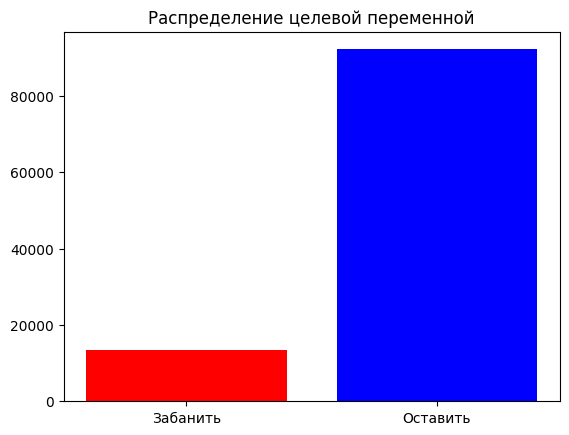

In [4]:
target = data_train['target'].value_counts()

plt.bar(['Забанить', 'Оставить'], [target.get(1, 0), target.get(0, 0)], color=['red', 'blue'])
plt.title('Распределение целевой переменной')
plt.show()

### 1.3 Работа с выбросами

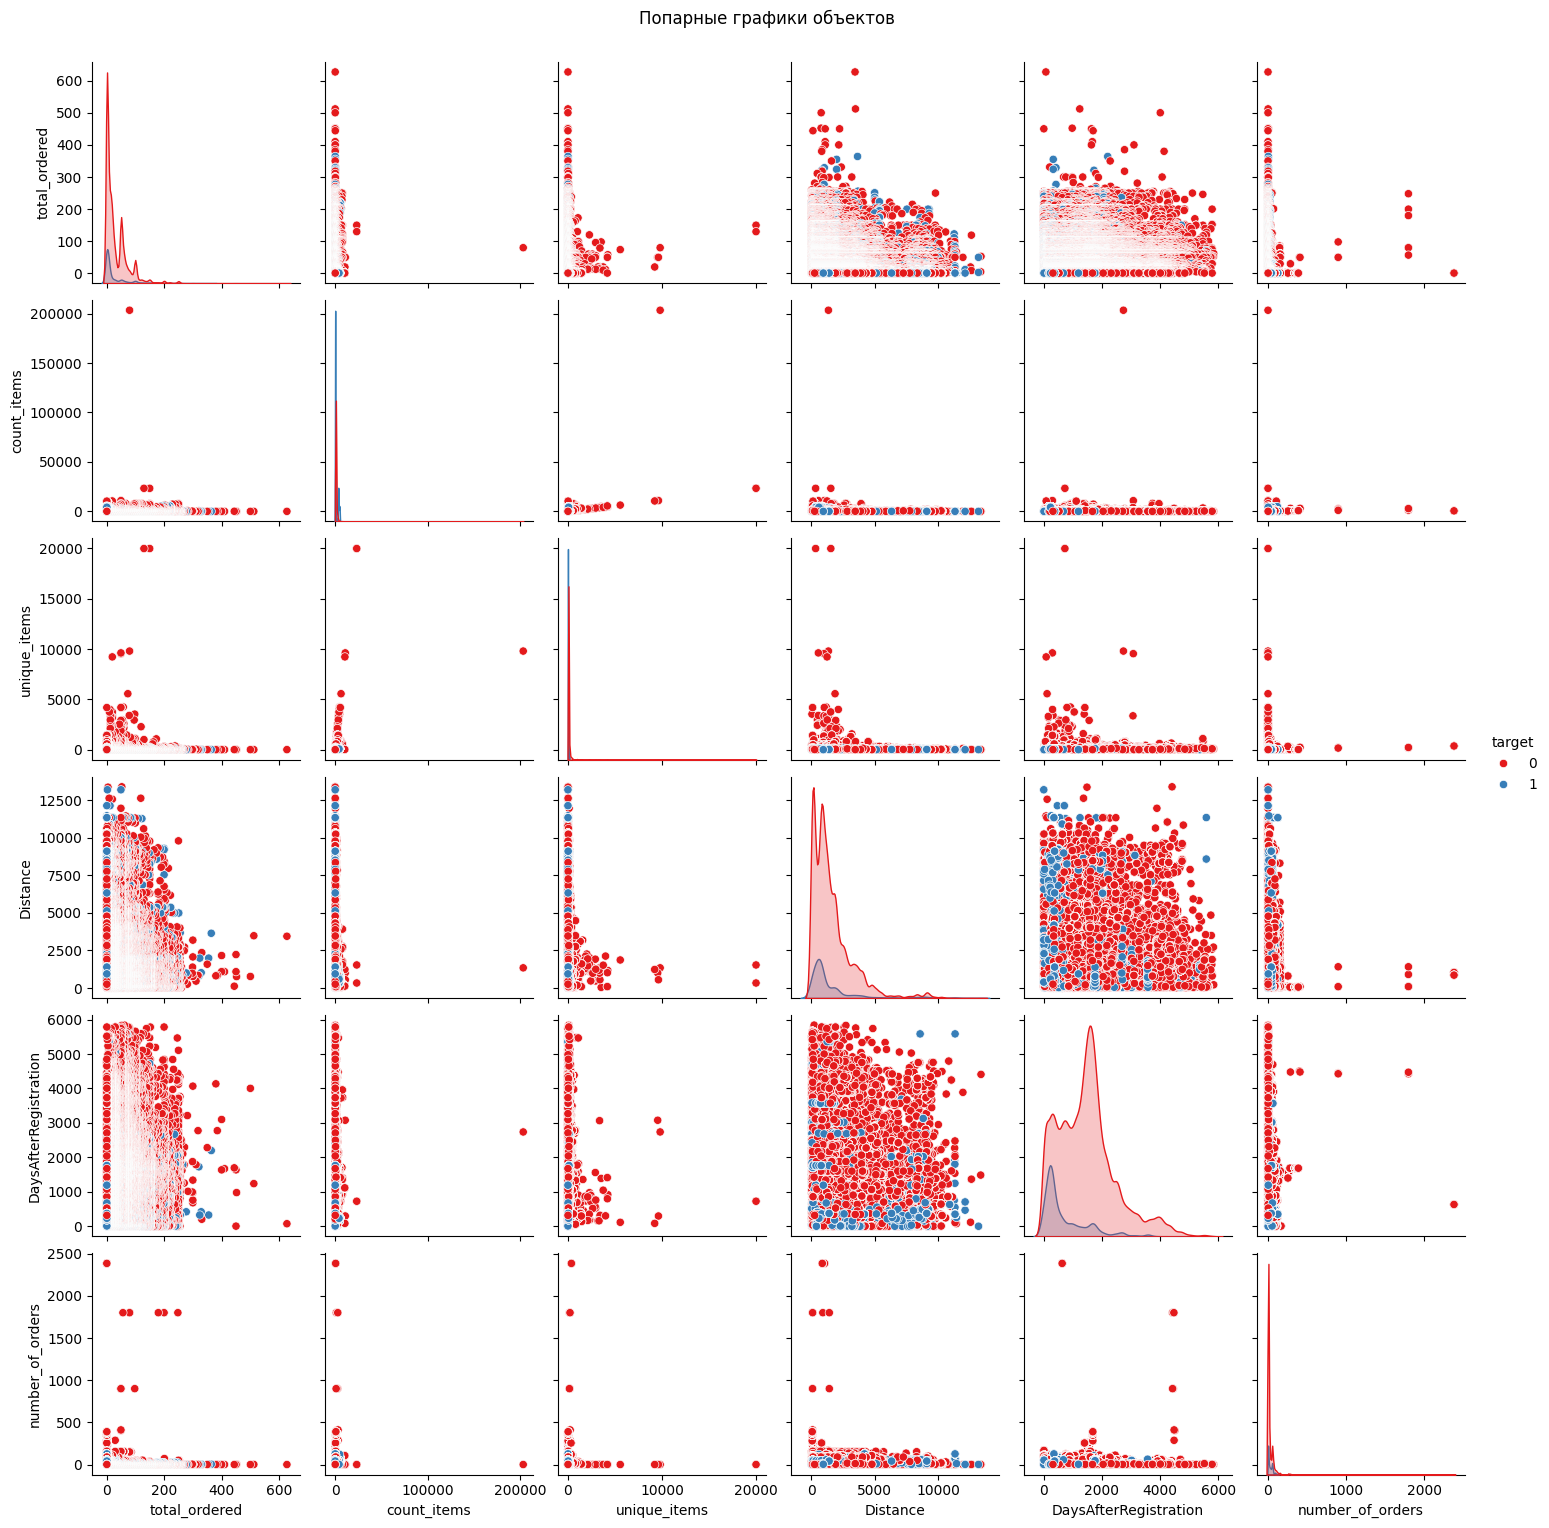

In [9]:
selected_features = ['total_ordered', 'count_items', 'unique_items', 'Distance',
                     'DaysAfterRegistration', 'number_of_orders', 'target']

sns.pairplot(data_train[selected_features], hue='target', palette='Set1', diag_kind='kde')
plt.suptitle('Попарные графики объектов', y=1.02)
plt.show()

<Axes: xlabel='DaysAfterRegistration', ylabel='Count'>

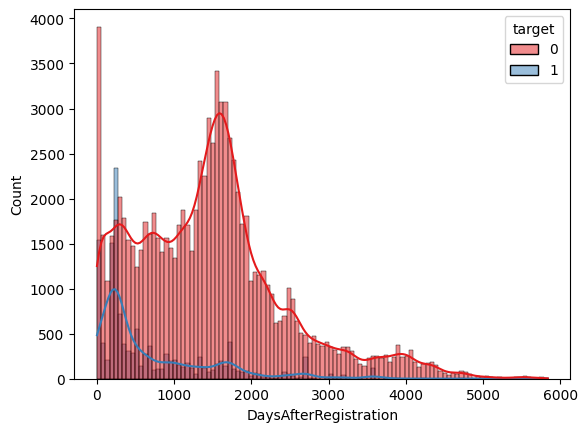

In [13]:
sns.histplot(data_train, x='DaysAfterRegistration', hue = 'target', palette='Set1', kde=True)


Попробовать поранжировать и увидеть, как меняется качество

In [5]:
data_train = data_train[data_train['total_ordered'] <= 400]
data_train = data_train[data_train['count_items'] <= 6000]
data_train = data_train[data_train['unique_items'] <= 600]
data_train = data_train[data_train['number_of_orders'] <= 130]

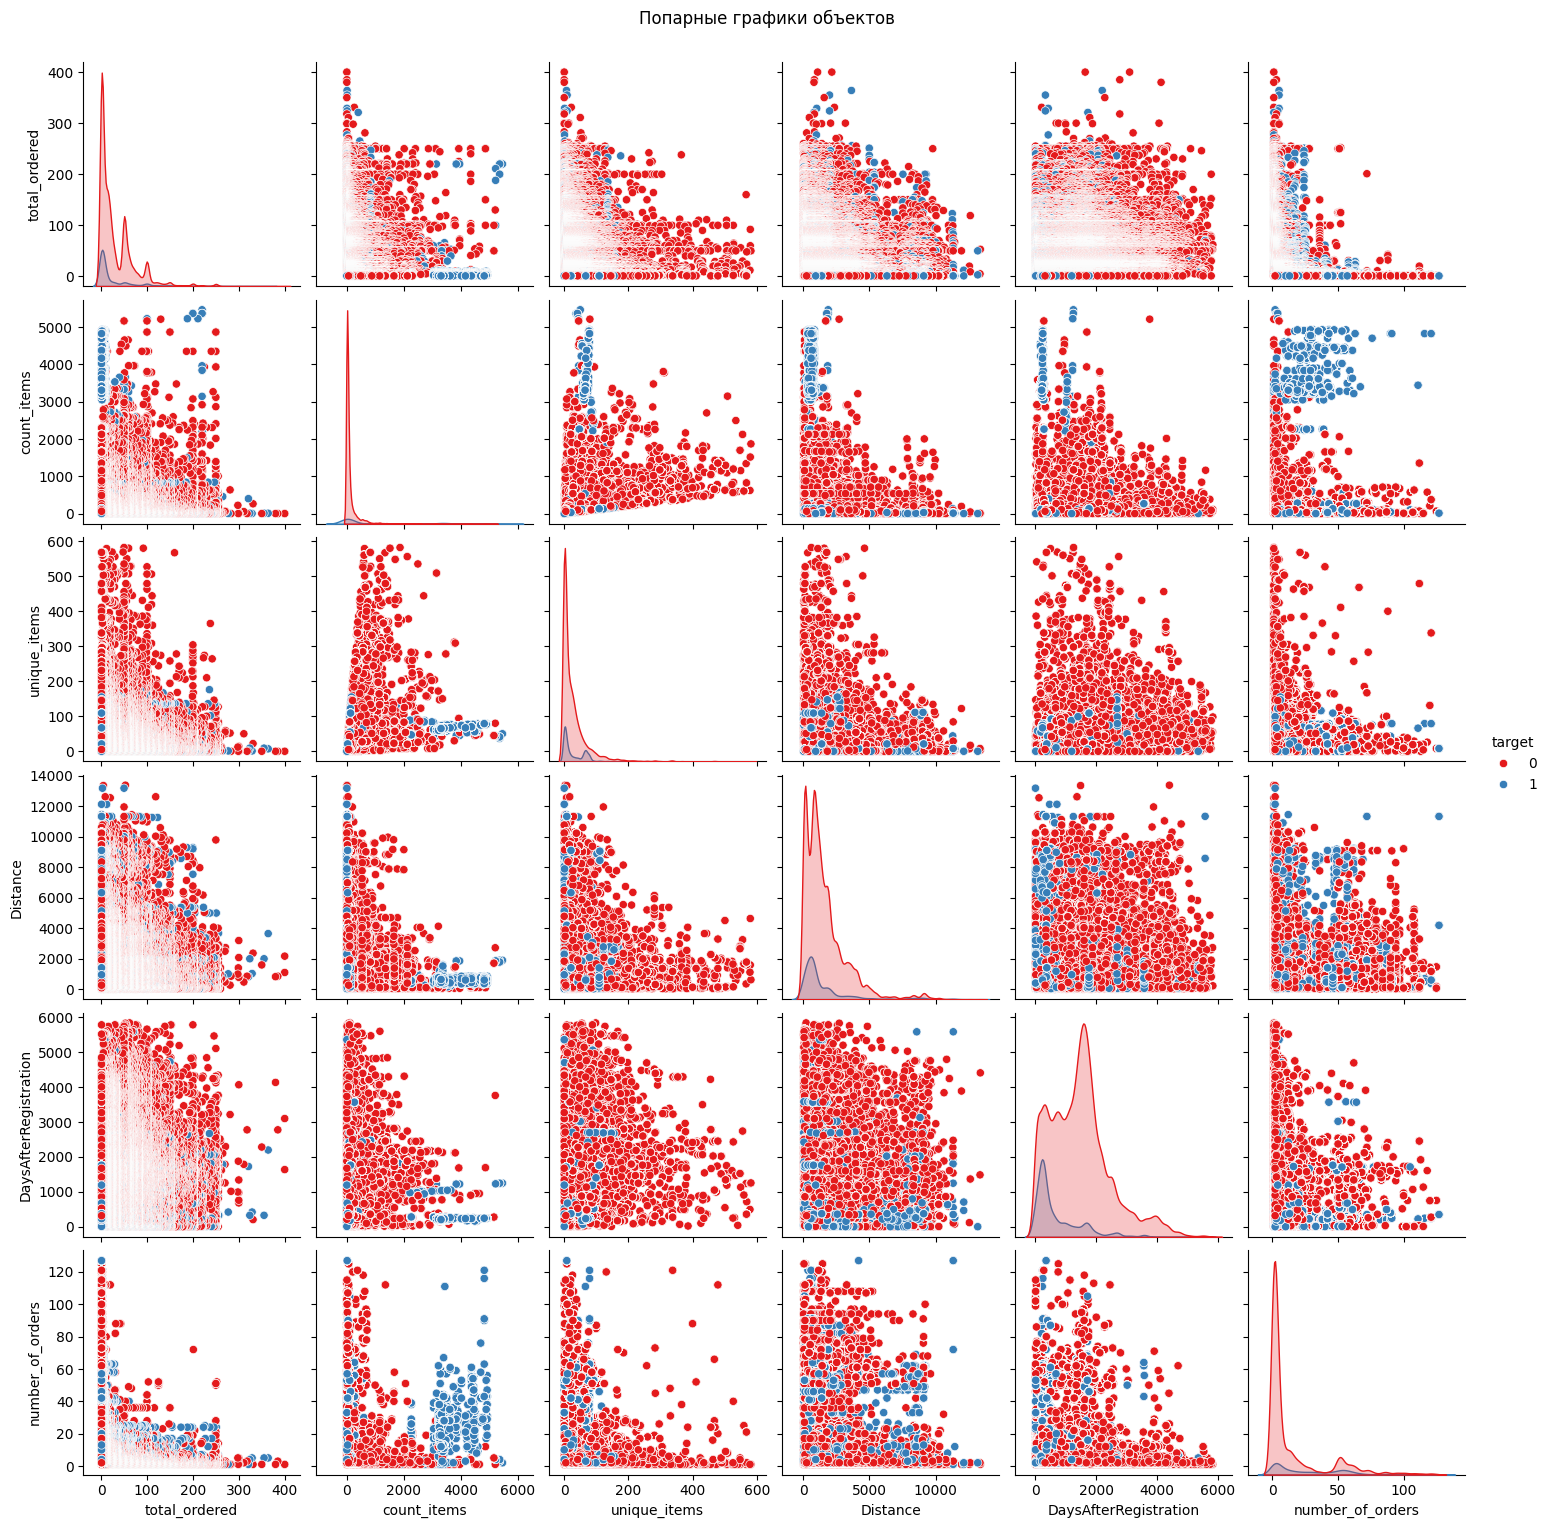

In [6]:
selected_features = ['total_ordered', 'count_items', 'unique_items', 'Distance',
                     'DaysAfterRegistration', 'number_of_orders', 'target']

sns.pairplot(data_train[selected_features], hue='target', palette='Set1', diag_kind='kde')
plt.suptitle('Попарные графики объектов', y=1.02)
plt.show()

In [7]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103390 entries, 8 to 105564
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   user_id                        103390 non-null  int64  
 1   nm_id                          103390 non-null  int64  
 2   CreatedDate                    103390 non-null  object 
 3   service                        103390 non-null  object 
 4   total_ordered                  103390 non-null  int64  
 5   PaymentType                    103390 non-null  object 
 6   IsPaid                         103390 non-null  bool   
 7   count_items                    103390 non-null  int64  
 8   unique_items                   103390 non-null  int64  
 9   avg_unique_purchase            103390 non-null  float64
 10  is_courier                     103390 non-null  int64  
 11  NmAge                          103390 non-null  int64  
 12  Distance                       1033

In [8]:
print('Количество типов оплаты -', data_train['PaymentType'].nunique())
for i in data_train['PaymentType'].unique():
    print(f"{i} - {data_train['PaymentType'].value_counts()[i]}")

Количество типов оплаты - 11
CRD - 25527
CSH - 67369
BAL - 7477
QRS - 190
MPM - 2160
CRE - 59
WPG - 79
PDL - 454
ACC - 73
CIN - 1
CWB - 1


In [9]:
data_train = data_train[~data_train['PaymentType'].isin(['CIN', 'CWB'])]

In [10]:
num_cols = data_train.select_dtypes(include=['int64','float64']).columns
data_train[num_cols].describe(percentiles=[.01,.25,.5,.75,.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
user_id,103388.0,21292.149408,12387.090412,2.000000,91.000000,9635.000000,22761.500000,34296.00,35407.0,35433.0
nm_id,103388.0,19574.857653,13380.764927,2.000000,51.000000,6263.000000,20918.500000,33674.25,37201.0,37224.0
total_ordered,103388.0,30.504459,40.420768,1.000000,1.000000,1.000000,14.000000,50.00,200.0,400.0
count_items,103388.0,230.956765,712.819575,0.000000,0.000000,0.000000,21.000000,99.00,4224.0,5466.0
unique_items,103388.0,30.004217,51.759752,0.000000,0.000000,0.000000,12.000000,39.00,269.0,582.0
avg_unique_purchase,103388.0,0.404569,0.407574,0.000000,0.000000,0.000000,0.250000,0.86,1.0,1.0
is_courier,103388.0,0.013512,0.115455,0.000000,0.000000,0.000000,0.000000,0.00,1.0,1.0
NmAge,103388.0,5539.358736,8678.928353,0.000000,4.000000,153.000000,360.000000,20004.00,20112.0,20120.0
Distance,103388.0,1575.607188,1663.979167,6.000000,35.000000,499.000000,1092.000000,2026.00,8978.0,13381.0
DaysAfterRegistration,103388.0,1366.996296,1002.077706,0.000000,0.000000,540.000000,1332.000000,1855.00,4337.0,5839.0


### 1.4 Обработка категориальных признаков

In [11]:
def preprocess_base(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['CreatedDate'] = pd.to_datetime(df['CreatedDate'], errors='coerce')
    df['year']    = df['CreatedDate'].dt.year
    df['month']   = df['CreatedDate'].dt.month
    df['weekday'] = df['CreatedDate'].dt.weekday
    df['weekend'] = (df['weekday'] >= 5).astype(int)

    df.drop([
        'mean_percent_of_ordered_items',
        'min_number_of_ordered_items',
        'max_number_of_ordered_items'
    ], axis=1, inplace=True, errors='ignore')
    valid_payment_types = {'CRD', 'CSH', 'BAL', 'QRS', 'MPM', 'CRE', 'WPG', 'PDL', 'ACC'}
    df['PaymentType'] = df['PaymentType'].where(df['PaymentType'].isin(valid_payment_types), 'CRD')

    df = pd.get_dummies(df, columns=['service', 'PaymentType'], dtype=int)

    for col in df.select_dtypes(include='bool').columns:
        df[col] = df[col].astype(int)

    return df


In [12]:
data_train = preprocess_base(data_train)

### 1.5 Добавление новых признаков

In [14]:
def add_features(df : pd.DataFrame) -> pd.DataFrame: 
    df = df.copy()  
    
    for col in ['count_items','unique_items',
                'total_ordered','Distance', 'number_of_orders']:
        df[f'{col}_log'] = np.log1p(df[col])

    df['far_and_large_order'] = ((df['Distance'] > df['Distance'].quantile(0.9)) & (df['total_ordered'] > df['total_ordered'].quantile(0.75))).astype(int)
    df['unique_to_total_ratio'] = df['unique_items'] / (df['total_ordered'] + 1e-6)
    df['order_vs_mean_order'] = df['total_ordered'] / (df['mean_number_of_ordered_items'] + 1e-6)
    df['product_popularity'] = df.groupby('nm_id')['total_ordered'].transform('count')

    user_counts = df['user_id'].value_counts()
    threshold = user_counts.quantile(0.95)
    df['user_order_count'] = df['user_id'].map(user_counts)
    df['is_frequent_user'] = (df['user_order_count'] >= threshold).astype(int)
    user_avg_order = df.groupby('user_id')['total_ordered'].mean()
    df['user_avg_total_ordered'] = df['user_id'].map(user_avg_order)
    user_max_ordered = df.groupby('user_id')['total_ordered'].max()
    df['user_max_ordered'] = df['user_id'].map(user_max_ordered)

    user_total_items = df.groupby('user_id')['count_items'].sum()
    user_total_unique_items = df.groupby('user_id')['unique_items'].sum()
    
    df['user_unique_items_ratio'] = (df['user_id'].map(user_total_unique_items) / 
                                 (df['user_id'].map(user_total_items) + 1e-6))

    avg_days_between = df.sort_values(['user_id', 'CreatedDate']).groupby('user_id')['CreatedDate'].diff().dt.days.groupby(df['user_id']).mean()
    df['user_avg_days_between_orders'] = df['user_id'].map(avg_days_between)
    df['is_anomalous_user'] = ((df['is_frequent_user'] == 1) & (df['user_avg_total_ordered'] > df['total_ordered'].quantile(0.95))).astype(int)

    
    
    df['ratio_current_to_mean'] = df['total_ordered'] / (df['mean_number_of_ordered_items']+1e-6)
    df['unique_share']          = df['unique_items']   / (df['count_items']+1e-6)
    df['order_rate']            = df['number_of_orders'] / (df['DaysAfterRegistration']+1)
    df['items_per_order']       = df['total_ordered']     / (df['number_of_orders']+1)
    
    df['is_new_user'] = (df['DaysAfterRegistration'] <= 7).astype(int)
    df['is_new_product'] = (df['NmAge'] <= 30).astype(int)
    df['far_distance'] = (df['Distance'] >= df['Distance'].quantile(0.9)).astype(int)
    df['new_large_combo'] = df['is_new_user'] & (df['total_ordered_log'] > np.log1p(50))
    df['pvz_large'] = (df['is_courier']==0) & (df['total_ordered_log'] > np.log1p(50))
    
    df['dist_km'] = df['Distance'] / 1000
    bins   = [0, 50, 200, 1000, np.inf]
    labels = ['<50','50-200','200-1000','>1000']
    df['dist_bin'] = pd.cut(df['dist_km'], bins=bins, labels=labels, right=False)
    df = pd.get_dummies(df, columns=['dist_bin'], prefix='dist', dtype=int)

    cat_cols = df.select_dtypes(include="object").columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols, dtype=int)

    SBP_SET      = {'QRS', 'MPM'}
    EWALLET_SET  = {'BAL', 'CWB'}

    df['is_sbp']     = df[[f'PaymentType_{c}' for c in SBP_SET if f'PaymentType_{c}' in df.columns]].any(axis=1).astype(int)
    df['is_ewallet'] = df[[f'PaymentType_{c}' for c in EWALLET_SET if f'PaymentType_{c}' in df.columns]].any(axis=1).astype(int)
    df.drop('CreatedDate', axis = 1, errors='ignore', inplace=True)
    df.drop("user_id", axis = 1)
    return df

In [15]:
data_train = add_features(data_train)

In [16]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103388 entries, 8 to 105564
Data columns (total 62 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       103388 non-null  int64  
 1   nm_id                         103388 non-null  int64  
 2   total_ordered                 103388 non-null  int64  
 3   IsPaid                        103388 non-null  int64  
 4   count_items                   103388 non-null  int64  
 5   unique_items                  103388 non-null  int64  
 6   avg_unique_purchase           103388 non-null  float64
 7   is_courier                    103388 non-null  int64  
 8   NmAge                         103388 non-null  int64  
 9   Distance                      103388 non-null  int64  
 10  DaysAfterRegistration         103388 non-null  int64  
 11  number_of_orders              103388 non-null  int64  
 12  number_of_ordered_items       103388 non-null  in

### 1.6 Обработка коррелирующих признаков

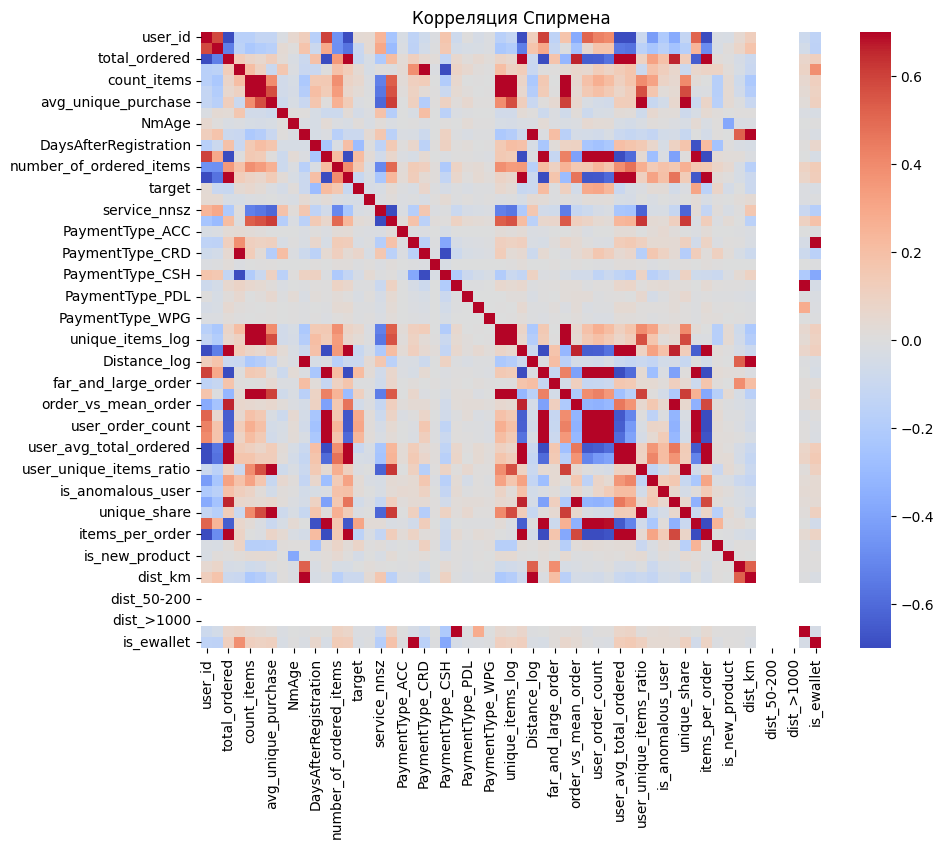

In [17]:
num_cols = data_train.select_dtypes(include=['int64','float64']).columns
corr = data_train[num_cols].corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmax=.7, vmin=-.7)
plt.title('Корреляция Спирмена')
plt.show()

In [18]:
def get_highly_correlated_features(df: pd.DataFrame, threshold: float = 0.7) -> list:
    corr_matrix = df.corr(method='spearman').abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = []
    for column in upper.columns:
        for row in upper.index:
            if upper.loc[row, column] > threshold:
                to_drop.append((row, column))

    return to_drop

In [19]:
cor_list = get_highly_correlated_features(data_train)

### 1.7 Обработка пропусков

In [20]:
def process_data(df: pd.DataFrame, correlated_features: list) -> pd.DataFrame:
    df = df.copy()

    mean_for_1 = df.loc[df['target'] == 1, 'user_avg_days_between_orders'].mean()
    mean_for_0 = df.loc[df['target'] == 0, 'user_avg_days_between_orders'].mean()

    df.loc[(df['target'] == 1) & (df['user_avg_days_between_orders'].isnull()), 'user_avg_days_between_orders'] = mean_for_1
    df.loc[(df['target'] == 0) & (df['user_avg_days_between_orders'].isnull()), 'user_avg_days_between_orders'] = mean_for_0

    columns_to_drop = ['user_id', 'nm_id']
    
    correlated_to_drop = list({pair[1] for pair in correlated_features})

    df.drop(columns=[col for col in (columns_to_drop + correlated_to_drop) if col in df.columns], inplace=True)

    return df

In [21]:
data_train = process_data(data_train, cor_list)

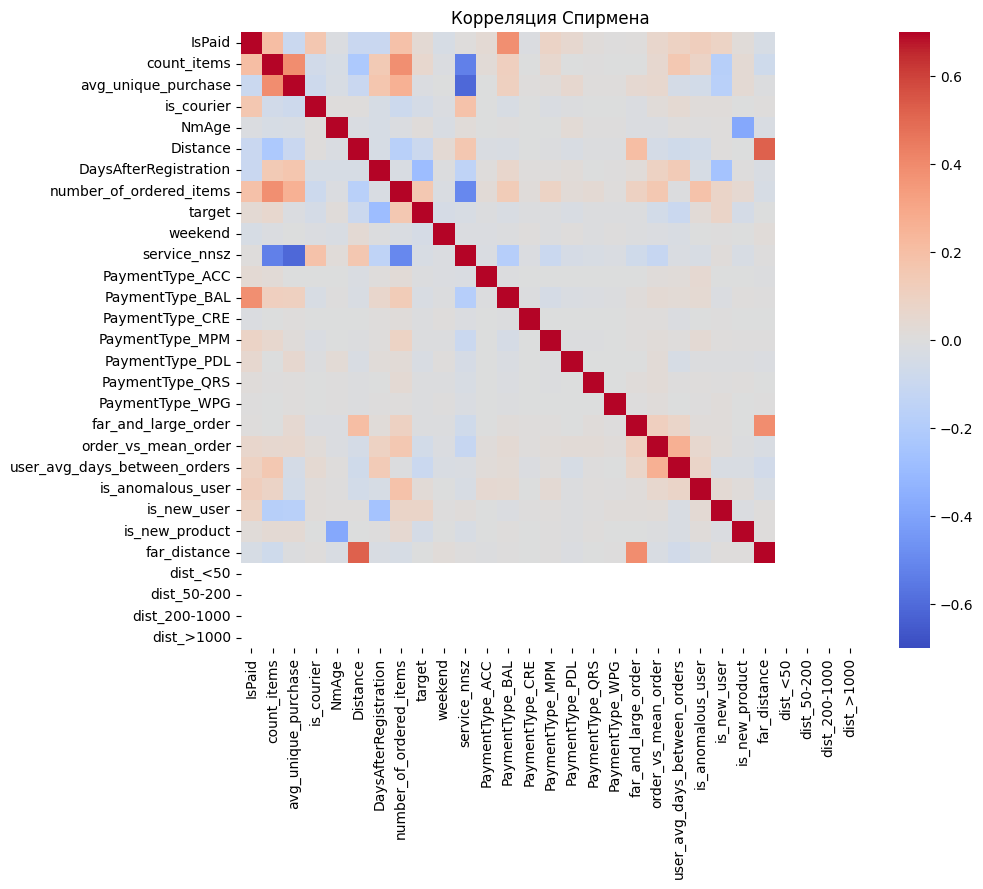

In [22]:
num_cols = data_train.select_dtypes(include=['int64','float64']).columns
corr = data_train[num_cols].corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmax=.7, vmin=-.7)
plt.title('Корреляция Спирмена')
plt.show()

### 1.8 Обработка теста 

In [23]:
data_test = process_data(add_features(preprocess_base(data_test)), cor_list)

In [24]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14261 entries, 0 to 14260
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   IsPaid                        14261 non-null  int64  
 1   count_items                   14261 non-null  int64  
 2   avg_unique_purchase           14261 non-null  float64
 3   is_courier                    14261 non-null  int64  
 4   NmAge                         14261 non-null  int64  
 5   Distance                      14261 non-null  int64  
 6   DaysAfterRegistration         14261 non-null  int64  
 7   number_of_ordered_items       14261 non-null  int64  
 8   target                        14261 non-null  int64  
 9   year                          14261 non-null  int32  
 10  month                         14261 non-null  int32  
 11  weekday                       14261 non-null  int32  
 12  weekend                       14261 non-null  int64  
 13  s

# Обучение

### 2.1 Разбитие данных

In [25]:
from catboost import CatBoostClassifier
from sklearn.metrics import precision_recall_curve

In [26]:
X_train, y_train = data_train.drop('target', axis=1), data_train['target']
X_test, y_test = data_test.drop('target', axis=1),  data_test['target']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train,
    test_size=0.2,      
    stratify=y_train,            
    random_state=42
)

### 2.2 Обучение

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    precision_recall_curve, classification_report, accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix, f1_score, precision_score, recall_score
)
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [29]:
X = data_train.drop('target', axis=1)
y = data_train['target']
X_test = data_test.drop('target', axis=1)
y_test = data_test['target']

In [30]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

In [33]:
X_transformed = preprocessor.fit_transform(X)
X_test_transformed = preprocessor.transform(X_test)

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_transformed, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
cb = CatBoostClassifier(
    iterations=400,
    depth=3,
    learning_rate=0.02,
    l2_leaf_reg=100000,
    class_weights=[1, 6],
    eval_metric="Precision",
    random_seed=42,
    verbose=False
)

lr = LogisticRegression(
    class_weight={0: 1, 1: 6},
    max_iter=800,
    solver='liblinear',
    random_state=42,
    C=0.00001
)

xgb = XGBClassifier(
    max_depth=3,
    scale_pos_weight=6,
    learning_rate=0.0001,
    n_estimators=300,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [37]:
cb.fit(X_train, y_train)
lr.fit(X_train, y_train)
xgb.fit(X_train, y_train)

c:\Users\chudp\wb-hackathon_1\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:15:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [38]:
ensemble = VotingClassifier(
    estimators=[
        ('catboost', cb),
        ('logreg', lr),
        ('xgboost', xgb)
    ],
    voting='soft',
    weights=[4, 5, 4]
)

In [39]:
ensemble.fit(X_train, y_train)

c:\Users\chudp\wb-hackathon_1\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:16:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimators,"[('catboost', ...), ('logreg', ...), ...]"
,voting,'soft'
,weights,"[4, 5, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e-05
,fit_intercept,True


### 2.3 Нахождение оптимальных гиперпараметров для валидации

In [40]:
y_valid_proba = ensemble.predict_proba(X_valid)[:, 1]
y_test_proba = ensemble.predict_proba(X_test_transformed)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_valid, y_valid_proba)

best = {'thr': 0, 'prec': 0, 'rec': 0}
for p, r, t in zip(precisions, recalls, thresholds):
    if 0.96 <= p <= 0.97:
        best = {'thr': t, 'prec': p, 'rec': r}
        break

y_valid_pred = (y_valid_proba >= best['thr']).astype(int)
y_test_pred = (y_test_proba >= best['thr']).astype(int)

### 2.4 Вывод результата метрик

In [41]:
def print_metrics(y_true, y_pred, y_prob, title=""):
    print(f"\n--- {title} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    
    if y_prob is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
        print(f"PR-AUC:    {average_precision_score(y_true, y_prob):.4f}")
    
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred))


    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



--- Validation ---
Accuracy:  0.9035
Precision: 0.9605
Recall:    0.2639
F1-score:  0.4141
ROC-AUC:   0.8804
PR-AUC:    0.6369

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     18007
           1       0.96      0.26      0.41      2671

    accuracy                           0.90     20678
   macro avg       0.93      0.63      0.68     20678
weighted avg       0.91      0.90      0.88     20678



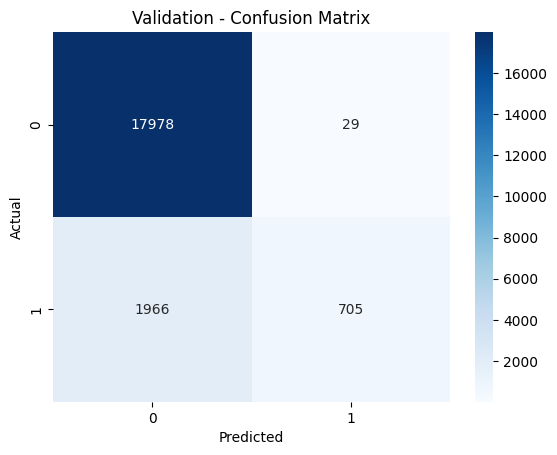


--- Test ---
Accuracy:  0.8912
Precision: 0.9262
Recall:    0.1528
F1-score:  0.2624
ROC-AUC:   0.6368
PR-AUC:    0.3539

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     12455
           1       0.93      0.15      0.26      1806

    accuracy                           0.89     14261
   macro avg       0.91      0.58      0.60     14261
weighted avg       0.89      0.89      0.86     14261



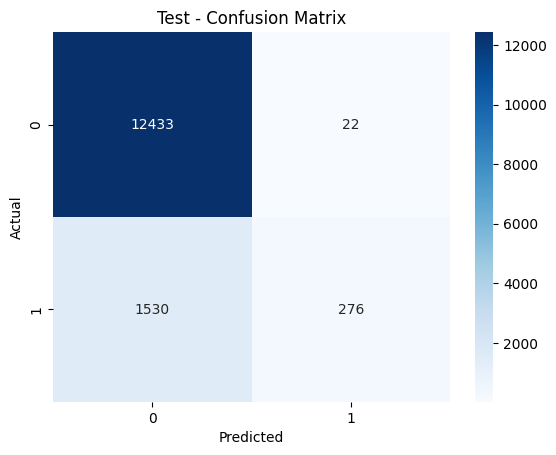

In [42]:
print_metrics(y_valid, y_valid_pred, y_valid_proba, title='Validation')
print_metrics(y_test, y_test_pred, y_test_proba, title='Test')

In [43]:
print(best)

{'thr': np.float64(0.6192686380300122), 'prec': np.float64(0.9604904632152589), 'rec': np.float64(0.2639460876076376)}
